In [1]:
import tensorflow as tf
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam


In [2]:
max_length = 15

In [3]:
import string

stopwords = []

with open('stopwords.txt', encoding='utf-8', errors='ignore') as f:
    for line in f:
        stopwords.append(line.strip())


stopwords

urdu_punctuation = "؛۔،؟!‘’“”()-"
table = str.maketrans('','',urdu_punctuation)

In [4]:
df = pd.read_csv('Urdu_dataset.csv')

# Process sentences to remove stopwords and punctuation
processed_sentences = []
for sentence in df['Sentence']:
    sentence = sentence.lower()
    sentence = sentence.replace(",", " , ")
    sentence = sentence.replace(".", " . ")
    sentence = sentence.replace("-", " - ")
    sentence = sentence.replace("/", " / ")
    words = sentence.split()
    filtered_sentence = ""
    for word in words:
        word = word.translate(table)
        if word not in stopwords:
            filtered_sentence = filtered_sentence + word + " "
    processed_sentences.append(filtered_sentence)

sentences = pd.Series(processed_sentences)
total_len = len(sentences)

sentences_train = sentences[:int(total_len*0.90)]

sentences_test = sentences[int(total_len*0.90):]


print(sentences_train.head())
print('\n',sentences_test.head())

0                 بہت گرمی 
1                چائے اچھی 
2              چائے لاجواب 
3              بہت مزہ آیا 
4    گیمز بہت مہنگے ہو گئے 
dtype: object

 45            ٹریفک قوانین عمل نہ کرنے سڑک حادثات ہوتے 
46                 کرپشن واجہ انصاف نظام کمزور ہو جاتا 
47                        رواداری صبر معاشرہ بہتر ہوتا 
48    کچھ لوگ صرف اپنا فائدہ دیکھتے جو کہ غیر ذمے داری 
49                 بہت گرمی روزمرہ کے کام مشکل ہو جاتا 
dtype: object


In [5]:
labels = df['Sentiment']

labels_train = labels[:int(total_len*0.90)]

labels_test = labels[int(total_len*0.90):]


print(labels_train.head())
print('\n',labels_test.head())

0    1
1    0
2    0
3    0
4    1
Name: Sentiment, dtype: int64

 45    1
46    1
47    0
48    1
49    1
Name: Sentiment, dtype: int64


In [6]:
#Tokens banana for both train and test data
vocab_size = 10000
tokenizer  = Tokenizer(num_words=vocab_size, oov_token = '<OOV>')


tokenizer.fit_on_texts(sentences_train)
word_idx = tokenizer.word_index

word_idx

{'<OOV>': 1,
 'میں': 2,
 'کے': 3,
 'بہت': 4,
 'لوگ': 5,
 'کچھ': 6,
 'اچھی': 7,
 'لیے': 8,
 'کام': 9,
 'طلباء': 10,
 'ہوتے': 11,
 'نے': 12,
 'کرنے': 13,
 'ہوتا': 14,
 'شہر': 15,
 'دیا': 16,
 'چائے': 17,
 'ہو': 18,
 'ہمارے': 19,
 'خیال': 20,
 'نہ': 21,
 'نقصان': 22,
 'واجہ': 23,
 'مدد': 24,
 'عوام': 25,
 'لوگون': 26,
 'رہی': 27,
 'باعزت': 28,
 'سلوک': 29,
 'بات': 30,
 'رشتے': 31,
 'مظبوط': 32,
 'غیر': 33,
 'جانوروں': 34,
 'ظلم': 35,
 'نہیں': 36,
 'رہے': 37,
 'لوڈ': 38,
 'شیڈنگ': 39,
 'معاشرے': 40,
 'ایک': 41,
 'مسئلہ': 42,
 'شجرکاری': 43,
 'مہم': 44,
 'سرسبز': 45,
 'آن': 46,
 'لائن': 47,
 'سیکھنے': 48,
 'نئے': 49,
 'مواقع': 50,
 'گرمی': 51,
 'لاجواب': 52,
 'مزہ': 53,
 'آیا': 54,
 'گیمز': 55,
 'مہنگے': 56,
 'گئے': 57,
 'محلے': 58,
 'اب': 59,
 'غریبوں': 60,
 'رکھتے': 61,
 'ٹریفک': 62,
 'قوانین': 63,
 'عمل': 64,
 'سب': 65,
 'سکولوں': 66,
 'تعلیم': 67,
 'مایار': 68,
 'بھیتر': 69,
 'حکومت': 70,
 'کرنا': 71,
 'چاہئیے': 72,
 'یوتھ': 73,
 'انٹرپرینیورشپ': 74,
 'ٹرینڈ': 75,
 'بڑہ': 76,
 'رہا': 77

In [7]:
# Text To Sequences
train_sequences = tokenizer.texts_to_sequences(sentences_train)
test_sequences = tokenizer.texts_to_sequences(sentences_test)

print(f'{train_sequences[0]} \n {test_sequences[0]}')


[4, 51] 
 [62, 63, 64, 21, 13, 98, 99, 11]


In [8]:
padded_seq_train = pad_sequences(
    train_sequences,
    max_length,
    padding = 'post',
    truncating = 'post'
)

padded_seq_test = pad_sequences(
    test_sequences,
    max_length,
    padding = 'post',
    truncating = 'post'
)

print(f'{padded_seq_train[0]} \n {padded_seq_test[0]}')

[ 4 51  0  0  0  0  0  0  0  0  0  0  0  0  0] 
 [62 63 64 21 13 98 99 11  0  0  0  0  0  0  0]


In [9]:
embedd_dim = 16

model = Sequential(
    [
        Embedding(vocab_size, embedd_dim),
        Bidirectional(LSTM(embedd_dim, return_sequences=True)),
        Bidirectional(LSTM(embedd_dim)),
        Dense(24, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

In [10]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, amsgrad=False),
    metrics = ['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
import numpy as np

padded_seq_train = np.array(padded_seq_train)
train_labels = np.array(labels_train)

padded_seq_test = np.array(padded_seq_test)
test_labels = np.array(labels_test)

In [13]:
history = model.fit(padded_seq_train, train_labels, epochs=100,batch_size=32, validation_data=(padded_seq_test, test_labels))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5556 - loss: 0.6931 - val_accuracy: 0.6000 - val_loss: 0.6921
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5556 - loss: 0.6929 - val_accuracy: 0.6000 - val_loss: 0.6923
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5333 - loss: 0.6927 - val_accuracy: 0.4000 - val_loss: 0.6927
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5111 - loss: 0.6925 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.6444 - loss: 0.6924 - val_accuracy: 0.4000 - val_loss: 0.6935
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.6444 - loss: 0.6922 - val_accuracy: 0.4000 - val_loss: 0.6939
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.6000 - loss: 0.6921 - val_accuracy: 0.4000 - val_loss: 0.6942
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.5333 - loss: 0.6919 - val_accuracy: 0.4000 - val

In [14]:
model.save('Urdu_Sarcasm_Detector.keras')

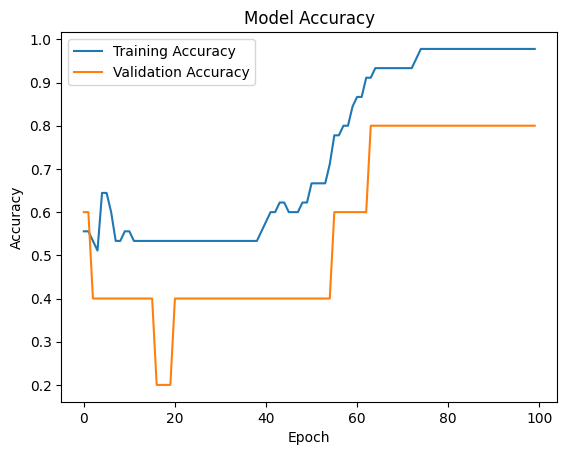

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

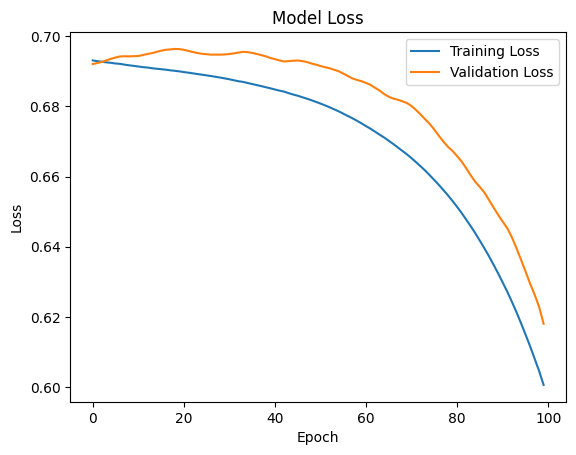

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [17]:
model.evaluate(padded_seq_test, test_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8000 - loss: 0.6181


[0.6180661916732788, 0.800000011920929]

In [18]:
predictions = model.predict(padded_seq_test)

for inference in predictions:
    if inference > 0.5:
        print('Negative Sentiment')
    else:
        print('Positive Sentiment')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Negative Sentiment
Negative Sentiment
Positive Sentiment
Negative Sentiment
Positive Sentiment


In [19]:
test_labels

array([1, 1, 0, 1, 1])